<a href="https://colab.research.google.com/github/boba-frog/Fraud-Detection/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
file_path = '/content/drive/MyDrive/DATASET/financial_fraud_detection_dataset.csv' # Replace with the actual path

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame loaded successfully!
  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            

In [ ]:
!pip install category_encoders

In [ ]:
!pip install imbalanced-learn

In [ ]:
#Printing out datatypes of variables-important for feature engineering.
df.info()
print("\nColumn Data Types:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [ ]:
#ENCODING PT1
# Columns to drop due to high cardinality or irrelevance for direct encoding:
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']

# Columns for one-hot encoding:
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel', 'location', 'device_hash']

print("Plan for encoding categorical variables:")
print(f"Columns to be dropped: {cols_to_drop}")
print(f"Columns for one-hot encoding: {cols_for_onehot}")

Plan for encoding categorical variables:
Columns to be dropped: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']
Columns for one-hot encoding: ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel', 'location', 'device_hash']


In [ ]:
# ENCODING PT2 - Safe One-Hot
import pandas as pd
import numpy as np

# Columns to drop
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']

# Columns for one-hot encoding (excluding fraud_type for safety)
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'payment_channel']
# fraud_type is dropped in this dataset, do not include
if 'fraud_type' in cols_for_onehot:
    cols_for_onehot.remove('fraud_type')

# Drop unnecessary columns
df_encoded = df.drop(columns=cols_to_drop, errors='ignore')

# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=cols_for_onehot, drop_first=True)

# Define X and y
target_col = 'is_fraud'
X_processed = df_encoded.drop(columns=[target_col], errors='ignore')
y = df_encoded[target_col]

# Verify
print("DataFrame after one-hot encoding:")
display(df_encoded.head())

print("\nData types of the encoded DataFrame:")
print(df_encoded.dtypes)

DataFrame after one-hot encoding:


,amount,location,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,device_hash,transaction_type_payment,...,merchant_category_restaurant,merchant_category_retail,merchant_category_travel,merchant_category_utilities,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer
0,343.78,Tokyo,False,NaN,NaN,-0.21,3,0.22,D8536477,False,...,False,False,False,True,True,False,False,False,True,False
1,419.65,Toronto,False,NaN,NaN,-0.14,7,0.96,D2622631,False,...,False,False,False,False,False,False,False,False,False,False
2,2773.86,London,False,NaN,NaN,-1.78,20,0.89,D4823498,False,...,False,False,False,False,False,True,False,False,True,False
3,1666.22,Sydney,False,NaN,NaN,-0.60,6,0.37,D9961380,False,...,False,False,False,False,False,True,False,False,False,True
4,24.43,Toronto,False,NaN,NaN,0.79,13,0.27,D7637601,False,...,False,False,False,True,True,False,False,False,False,False



Data types of the encoded DataFrame:
amount                           float64
location                          object
is_fraud                            bool
fraud_type                        object
time_since_last_transaction      float64
spending_deviation_score         float64
velocity_score                     int64
geo_anomaly_score                float64
device_hash                       object
transaction_type_payment            bool
transaction_type_transfer           bool
transaction_type_withdrawal         bool
merchant_category_grocery           bool
merchant_category_online            bool
merchant_category_other             bool
merchant_category_restaurant        bool
merchant_category_retail            bool
merchant_category_travel            bool
merchant_category_utilities         bool
device_used_mobile                  bool
device_used_pos                     bool
device_used_web                     bool
payment_channel_UPI                 bool
payment_channel_car

Training subset shape after SMOTE: (1436420, 21)
Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud               560526           403563
Actual Fraud                    20790            15121

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.58      0.73    964089
        True       0.04      0.42      0.07     35911

    accuracy                           0.58   1000000
   macro avg       0.50      0.50      0.40   1000000
weighted avg       0.93      0.58      0.70   1000000



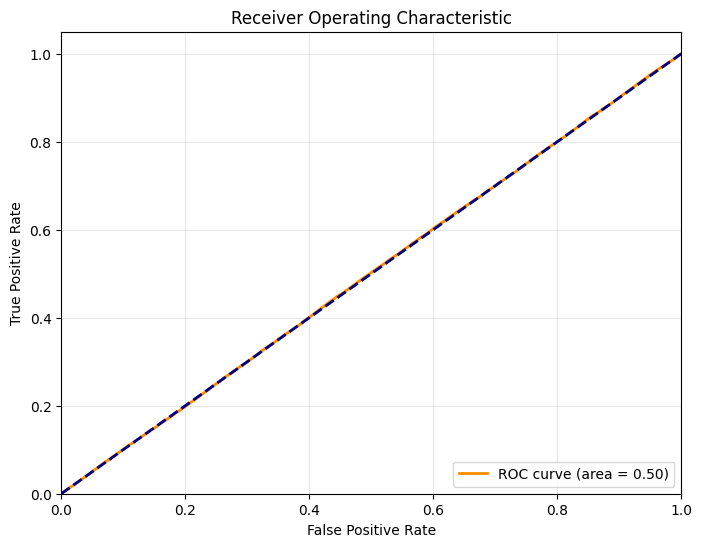

ROC AUC Score: 0.5008


In [ ]:
# -----------------------
# Split the data
# -----------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Drop remaining non-numeric columns before training
X_numeric = X_processed.select_dtypes(include=[np.number, 'bool'])

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# Reset indices
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# -----------------------
# Impute missing values
# -----------------------
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# -----------------------
# Efficient handling of high imbalance
# -----------------------
minority_mask = y_train == 1
majority_mask = y_train == 0

X_train_minority = X_train[minority_mask]
y_train_minority = y_train[minority_mask]

X_train_majority = X_train[majority_mask]
y_train_majority = y_train[majority_mask]

# Randomly sample majority
majority_sample_size = len(y_train_minority) * 5
majority_indices_sampled = np.random.choice(X_train_majority.index, size=majority_sample_size, replace=False)
X_train_majority_sampled = X_train_majority.loc[majority_indices_sampled]
y_train_majority_sampled = y_train_majority.loc[majority_indices_sampled]

X_train_subset = pd.concat([X_train_minority, X_train_majority_sampled])
y_train_subset = pd.concat([y_train_minority, y_train_majority_sampled])

# -----------------------
# Apply SMOTE
# -----------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_subset, y_train_subset)

print(f"Training subset shape after SMOTE: {X_train_res.shape}")

# -----------------------
# Train Model
# -----------------------
model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
model.fit(X_train_res, y_train_res)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# -----------------------
# Evaluation
# -----------------------
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=['Actual Non-Fraud', 'Actual Fraud'], columns=['Predicted Non-Fraud', 'Predicted Fraud']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC Score and Curve
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud               577594           386495
Actual Fraud                    21487            14424

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.60      0.74    964089
        True       0.04      0.40      0.07     35911

    accuracy                           0.59   1000000
   macro avg       0.50      0.50      0.40   1000000
weighted avg       0.93      0.59      0.71   1000000



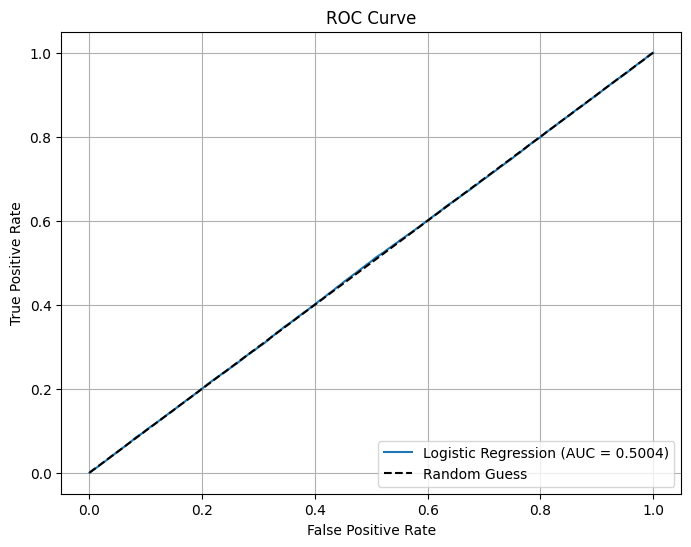

ROC AUC Score: 0.5004

--- Data Leakage Analysis ---
Mismatches (Potential leak column populated but is_fraud is False): {'fraud_type': 0}

Top correlations with is_fraud:
is_fraud                     1.000000
transaction_type_transfer    0.001062
merchant_category_other      0.000412
velocity_score               0.000370
geo_anomaly_score            0.000311
Name: is_fraud, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# 1. Train the model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_res, y_train_res)

# 2. Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 3. Evaluation Metrics
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Non-Fraud', 'Actual Fraud'], columns=['Predicted Non-Fraud', 'Predicted Fraud'])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

# 4. Data Leakage Checks
print("\n--- Data Leakage Analysis ---")
# Only check columns that actually exist in df_encoded
possible_leak_cols = ['fraud_type']
existing_leak_cols = [col for col in possible_leak_cols if col in df_encoded.columns]

if existing_leak_cols:
    leakage_check = {}
    for col in existing_leak_cols:
        mismatch = df_encoded[(df_encoded[col].notnull()) & (df_encoded['is_fraud'] == False)]
        leakage_check[col] = len(mismatch)
    print("Mismatches (Potential leak column populated but is_fraud is False):", leakage_check)
else:
    print("No specific leakage columns found in the encoded dataframe.")

# Top Correlations (Ensuring only numeric data is passed to .corr())
numeric_df = df_encoded.select_dtypes(include=[np.number, 'bool'])
correlations = numeric_df.corr()['is_fraud'].sort_values(ascending=False)
print("\nTop correlations with is_fraud:")
print(correlations.head(5))

Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud               577594           386495
Actual Fraud                    21487            14424

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.60      0.74    964089
        True       0.04      0.40      0.07     35911

    accuracy                           0.59   1000000
   macro avg       0.50      0.50      0.40   1000000
weighted avg       0.93      0.59      0.71   1000000



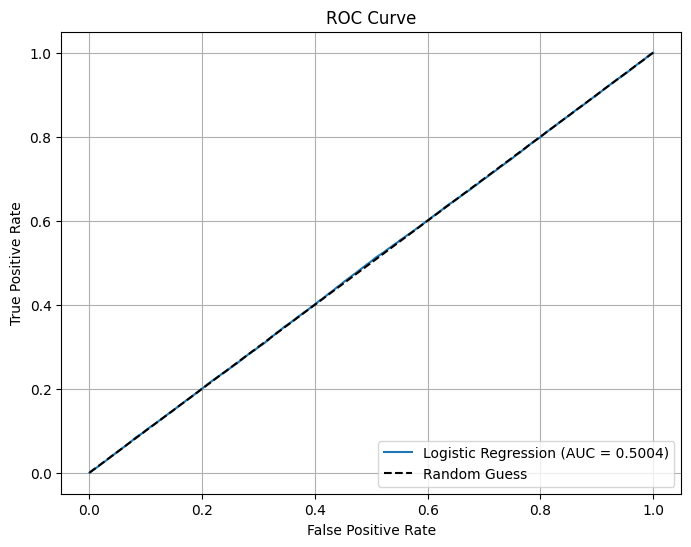

ROC AUC Score: 0.5004

--- Data Leakage Analysis ---
Checking potential leakage columns: ['fraud_type']
Mismatches (Fraud type exists but is_fraud is False): {'fraud_type': 0}


ValueError: could not convert string to float: 'Tokyo'

In [ ]:
#DO NOT RUN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Train the model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_res, y_train_res)

# 2. Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 3. Evaluation Metrics
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Non-Fraud', 'Actual Fraud'], columns=['Predicted Non-Fraud', 'Predicted Fraud'])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

# 4. Data Leakage Checks
print("\n--- Data Leakage Analysis ---")
fraud_type_cols = [col for col in X_processed.columns if 'fraud_type' in col]
print(f"Checking potential leakage columns: {fraud_type_cols}")

# Investigate 'fraud_type' logic: If 1 only when is_fraud is True, it's a leak.
leakage_check = {}
for col in fraud_type_cols:
    mismatch = df_encoded[(df_encoded[col] == True) & (df_encoded['is_fraud'] == False)]
    leakage_check[col] = len(mismatch)
print("Mismatches (Fraud type exists but is_fraud is False):", leakage_check)

# Top Correlations
correlations = df_encoded.corr()['is_fraud'].sort_values(ascending=False)
print("\nTop correlations with is_fraud:")
print(correlations.head(5))

Logistic Regression Model Evaluation:

Confusion Matrix:
[[951616  12473]
 [  3503  32408]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.99      0.99    964089
        True       0.72      0.90      0.80     35911

    accuracy                           0.98   1000000
   macro avg       0.86      0.94      0.90   1000000
weighted avg       0.99      0.98      0.98   1000000



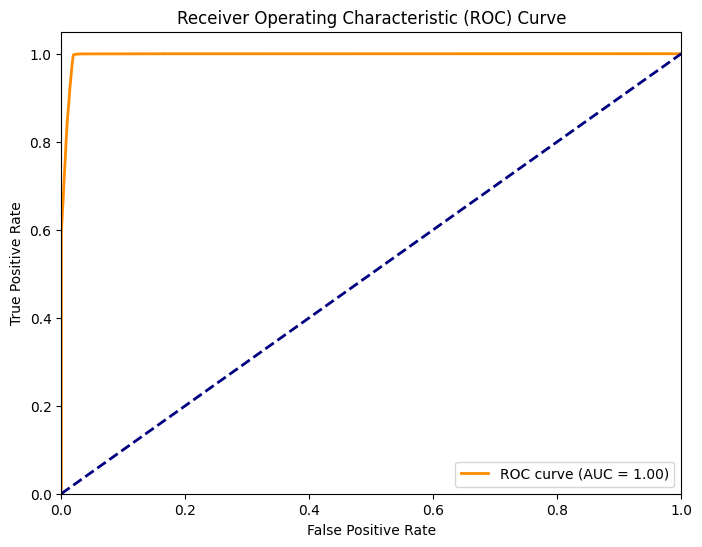


ROC AUC Score: 0.9965


In [ ]:
#DO NOT RUN
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Use the encoded and resampled data from the previous cell
# X_train_res, y_train_res, X_test, y_test are available from the previous cell execution

# -----------------------
# Train Logistic Regression model
# -----------------------
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for smaller datasets
log_reg_model.fit(X_train_res, y_train_res)

# -----------------------
# Evaluate the model
# -----------------------
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Evaluation:")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")